# Notebook 02 — Data Cleaning & ETL Pipeline
**NST DVA Capstone 2 | Healthcare Sector — Diabetic Patient Readmission**

| Field | Detail |
|---|---|
| **Input** | `data/raw/diabetic_data.csv` |
| **Output** | `data/processed/diabetic_data_clean.csv` |
| **Pipeline Stage** | Extract → **Clean & Transform** → Analyze → Load |
| **Raw Shape** | 101,766 rows × 50 columns |

> ⚠️ **Rule:** The raw file in `data/raw/` is NEVER modified. This notebook only reads it.

---

## Cell 1 — Install & Import Libraries

In [73]:
# Uncomment if running on Google Colab
# !pip install pandas numpy matplotlib seaborn --quiet

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print('Libraries loaded successfully.')
print(f'  pandas  : {pd.__version__}')
print(f'  numpy   : {np.__version__}')

Libraries loaded successfully.
  pandas  : 3.0.2
  numpy   : 2.4.4


## Cell 2 — Path Configuration

In [74]:
RAW_PATH       = '../data/raw/diabetic_data.csv'
PROCESSED_DIR  = '../data/processed/'
PROCESSED_PATH = PROCESSED_DIR + 'diabetic_data_clean.csv'
LOG_PATH       = PROCESSED_DIR + '02_cleaning_log.txt'

os.makedirs(PROCESSED_DIR, exist_ok=True)

if not os.path.exists(RAW_PATH):
    raise FileNotFoundError(f'Raw file not found: {RAW_PATH}. Place diabetic_data.csv in data/raw/')

print(f'Raw file   : {RAW_PATH}  ({os.path.getsize(RAW_PATH)/1e6:.1f} MB)')
print(f'Output dir : {PROCESSED_DIR}')

Raw file   : ../data/raw/diabetic_data.csv  (19.2 MB)
Output dir : ../data/processed/


## Cell 3 — Load Raw Dataset

In [75]:
# '?' is the missing-value marker used throughout this UCI dataset
df = pd.read_csv(RAW_PATH, na_values=['?', ''], low_memory=False)

RAW_ROWS, RAW_COLS = df.shape
print(f'Loaded: {RAW_ROWS:,} rows x {RAW_COLS} columns')

# Transformation log — every step appended here, written to file at the end
log = []
def record(step, description, rows_before=None, rows_after=None):
    msg = f'[STEP {step:02d}] {description}'
    if rows_before is not None:
        removed = rows_before - rows_after
        msg += f'  |  rows: {rows_before:,} -> {rows_after:,}  (removed {removed:,})'
    log.append(msg)
    print(msg)

record(0, f'Raw dataset loaded: {RAW_ROWS:,} rows x {RAW_COLS} cols')

Loaded: 101,766 rows x 50 columns
[STEP 00] Raw dataset loaded: 101,766 rows x 50 cols


## Cell 4 — Pre-Cleaning Snapshot
Quick audit of the raw data before any changes are made.

In [76]:
null_pct = (df.isnull().mean() * 100).round(1)
audit = pd.DataFrame({
    'dtype'      : df.dtypes,
    'null_count' : df.isnull().sum(),
    'null_%'     : null_pct,
    'unique'     : df.nunique()
})

print('=== PRE-CLEANING AUDIT ===')
print(audit.to_string())
print(f'\nTotal nulls: {df.isnull().sum().sum():,}')

=== PRE-CLEANING AUDIT ===
                          dtype  null_count  null_%  unique
encounter_id              int64           0    0.00  101766
patient_nbr               int64           0    0.00   71518
race                        str        2273    2.20       5
gender                      str           0    0.00       3
age                         str           0    0.00      10
weight                      str       98569   96.90       9
admission_type_id         int64           0    0.00       8
discharge_disposition_id  int64           0    0.00      26
admission_source_id       int64           0    0.00      17
time_in_hospital          int64           0    0.00      14
payer_code                  str       40256   39.60      17
medical_specialty           str       49949   49.10      72
num_lab_procedures        int64           0    0.00     118
num_procedures            int64           0    0.00       7
num_medications           int64           0    0.00      75
number_outpat

## Cell 5 — STEP 01: Drop Zero-Variance Columns

**Why:** `examide` and `citoglipton` contain only one unique value (`No`) across all 101,766 rows.
Columns with zero variance carry no information and add unnecessary width to the dataset.

In [77]:
zero_var_cols = [c for c in df.columns if df[c].nunique(dropna=True) == 1]
print(f'Zero-variance columns found: {zero_var_cols}')

df.drop(columns=zero_var_cols, inplace=True)
record(1, f'Dropped zero-variance columns: {zero_var_cols}')
print(f'Shape after step 01: {df.shape}')

Zero-variance columns found: ['examide', 'citoglipton']
[STEP 01] Dropped zero-variance columns: ['examide', 'citoglipton']
Shape after step 01: (101766, 48)


## Cell 6 — STEP 02: Drop `weight` Column

**Why:** `weight` has 96.9% missing values (98,569 out of 101,766 rows).
At this missingness level, any imputation strategy would fabricate data rather than fill it.
The column is dropped entirely. Weight is not a KPI for this readmission study.

In [78]:
weight_miss = df['weight'].isnull().mean() * 100
print(f'weight missingness: {weight_miss:.1f}%')

df.drop(columns=['weight'], inplace=True)
record(2, f'Dropped weight column ({weight_miss:.1f}% missing — imputation not viable)')
print(f'Shape after step 02: {df.shape}')

weight missingness: 96.9%
[STEP 02] Dropped weight column (96.9% missing — imputation not viable)
Shape after step 02: (101766, 47)


## Cell 7 — STEP 03: Remove Deceased & Hospice Patients

**Why:** Readmission analysis only makes sense for patients who were discharged alive.
Discharge disposition IDs 11, 13, 14, 19, 20, 21 correspond to death or hospice transfer
in the ICD coding system. Including them would artificially lower the readmission rate.

In [79]:
EXPIRED_CODES = [11, 13, 14, 19, 20, 21]
before = len(df)

df = df[~df['discharge_disposition_id'].isin(EXPIRED_CODES)].copy()

record(3, f'Removed deceased/hospice patients (discharge IDs: {EXPIRED_CODES})', before, len(df))

[STEP 03] Removed deceased/hospice patients (discharge IDs: [11, 13, 14, 19, 20, 21])  |  rows: 101,766 -> 99,343  (removed 2,423)


## Cell 8 — STEP 04: Deduplicate — Keep First Encounter Per Patient

**Why:** 71,518 patients appear more than once (multiple hospital visits).
In a readmission study, using multiple rows for the same patient leaks information
(a later visit IS the readmission event). We keep only the earliest encounter per patient.

In [80]:
before = len(df)
multi_enc = df['patient_nbr'].duplicated().sum()
print(f'Patients with multiple encounters: {multi_enc:,}')

# Sort by encounter_id (ascending = chronological) then keep first per patient
df = df.sort_values('encounter_id').drop_duplicates(subset='patient_nbr', keep='first').copy()

record(4, 'Kept first encounter per patient_nbr to prevent data leakage in readmission analysis', before, len(df))
print(f'Unique patients remaining: {df["patient_nbr"].nunique():,}')

Patients with multiple encounters: 29,353
[STEP 04] Kept first encounter per patient_nbr to prevent data leakage in readmission analysis  |  rows: 99,343 -> 69,990  (removed 29,353)
Unique patients remaining: 69,990


## Cell 9 — STEP 05: Fill Missing Values

**Strategy per column:**
- `max_glu_serum` / `A1Cresult` → `'None'` — null means the test was simply not ordered, which is a valid clinical category
- `medical_specialty` → `'Unknown'` — specialty not documented at admission
- `payer_code` → `'Unknown'` — insurance not recorded
- `admission_source_id` ID=17, `admission_type_id` ID=6, `discharge_disposition_id` ID=18 → these are ICD-defined NULL codes, handled in the label mapping step
- `race` → mode (`Caucasian`) — small missingness (2.2%)
- `diag_1` → mode of primary diagnosis — only 10 rows missing
- `diag_2` / `diag_3` → `'0'` — no secondary/tertiary diagnosis recorded (clinically valid)

In [81]:
# max_glu_serum — 'None' means not tested
df['max_glu_serum'] = df['max_glu_serum'].fillna('None')
print(f"max_glu_serum distribution: {df['max_glu_serum'].value_counts().to_dict()}")

# A1Cresult — 'None' means not tested
df['A1Cresult'] = df['A1Cresult'].fillna('None')
print(f"A1Cresult distribution: {df['A1Cresult'].value_counts().to_dict()}")

# medical_specialty
df['medical_specialty'] = df['medical_specialty'].fillna('Unknown')
print(f"medical_specialty nulls remaining: {df['medical_specialty'].isnull().sum()}")

# payer_code
df['payer_code'] = df['payer_code'].fillna('Unknown')
print(f"payer_code nulls remaining: {df['payer_code'].isnull().sum()}")

# race — mode imputation
race_mode = df['race'].mode()[0]
df['race'] = df['race'].fillna(race_mode)
print(f"race: filled with mode '{race_mode}'. Nulls remaining: {df['race'].isnull().sum()}")

# diag_1 — primary diagnosis, 10 rows missing
diag1_mode = df['diag_1'].mode()[0]
df['diag_1'] = df['diag_1'].fillna(diag1_mode)
print(f"diag_1: filled with mode '{diag1_mode}'. Nulls remaining: {df['diag_1'].isnull().sum()}")

# diag_2 / diag_3 — '0' = no secondary/tertiary diagnosis
df['diag_2'] = df['diag_2'].fillna('0')
df['diag_3'] = df['diag_3'].fillna('0')
print(f"diag_2/diag_3 nulls remaining: {df['diag_2'].isnull().sum()} / {df['diag_3'].isnull().sum()}")

record(5, 'Filled all missing values: max_glu_serum/A1Cresult->None, specialty/payer->Unknown, race->mode, diag_2/3->0')
print(f'\nTotal nulls after step 05: {df.isnull().sum().sum()}')

max_glu_serum distribution: {'None': 66641, 'Norm': 1701, '>200': 936, '>300': 712}
A1Cresult distribution: {'None': 57144, '>8': 6239, 'Norm': 3741, '>7': 2866}
medical_specialty nulls remaining: 0
payer_code nulls remaining: 0
race: filled with mode 'Caucasian'. Nulls remaining: 0
diag_1: filled with mode '414'. Nulls remaining: 0
diag_2/diag_3 nulls remaining: 0 / 0
[STEP 05] Filled all missing values: max_glu_serum/A1Cresult->None, specialty/payer->Unknown, race->mode, diag_2/3->0

Total nulls after step 05: 0


## Cell 10 — STEP 06: Convert Age Bracket → Numeric Midpoint

**Why:** Age is stored as bracket strings like `[70-80)`. Converting to the numeric midpoint (75)
enables correlation analysis, regression modelling, and proper axis scaling in Tableau.
The original bracket string is preserved in a new `age_bracket` column.

In [82]:
AGE_MAP = {
    '[0-10)'  :  5,
    '[10-20)' : 15,
    '[20-30)' : 25,
    '[30-40)' : 35,
    '[40-50)' : 45,
    '[50-60)' : 55,
    '[60-70)' : 65,
    '[70-80)' : 75,
    '[80-90)' : 85,
    '[90-100)': 95
}

df['age_bracket'] = df['age']          # preserve original
df['age'] = df['age'].map(AGE_MAP)

unmapped = df['age'].isnull().sum()
if unmapped > 0:
    df['age'].fillna(df['age'].median(), inplace=True)
    print(f'  Warning: {unmapped} age values unmapped — filled with median')

print(f'age range: {df["age"].min()} – {df["age"].max()}')
print(f'age distribution:\n{df["age"].value_counts().sort_index().to_string()}')

record(6, 'age: bracket string -> numeric midpoint (e.g. [70-80) -> 75). Original kept in age_bracket')

age range: 5 – 95
age distribution:
age
5       153
15      534
25     1121
35     2692
45     6828
55    12351
65    15689
75    17751
85    11110
95     1761
[STEP 06] age: bracket string -> numeric midpoint (e.g. [70-80) -> 75). Original kept in age_bracket


## Cell 11 — STEP 07: Map ICD Admission/Discharge Codes → Readable Labels

**Why:** The raw integer codes (`admission_type_id` = 1, 2, 3…) are meaningless without the
ICD reference lookup. Mapping them to descriptive labels makes the Tableau dashboard
self-explanatory and eliminates the need for a legend decoder.

In [83]:
ADMISSION_TYPE_MAP = {
    1: 'Emergency',      2: 'Urgent',         3: 'Elective',
    4: 'Newborn',        5: 'Not Available',   6: 'Not Available',
    7: 'Trauma Center',  8: 'Not Mapped'
}

DISCHARGE_DISPOSITION_MAP = {
    1 : 'Discharged to Home',
    2 : 'Transferred to SNF',
    3 : 'Transferred to SNF',
    4 : 'Transferred to ICF',
    5 : 'Transferred to Another Facility',
    6 : 'Home with Home Health',
    7 : 'Left AMA',
    8 : 'Home IV Therapy',
    9 : 'Admitted as Inpatient',
    10: 'Neonate Transferred',
    12: 'Still Patient',
    15: 'Swing Bed',
    16: 'Outpatient',
    17: 'Outpatient',
    18: 'Not Available',
    22: 'Rehab Facility',
    23: 'Long-term Care',
    24: 'Long-term Care',
    25: 'Not Mapped',
    26: 'Unknown',
    27: 'Inpatient Rehabilitation',
    28: 'Inpatient Rehabilitation',
    29: 'Outpatient Rehabilitation',
    30: 'Outpatient Rehabilitation'
}

ADMISSION_SOURCE_MAP = {
    1 : 'Physician Referral',
    2 : 'Clinic Referral',
    3 : 'HMO Referral',
    4 : 'Transfer from Hospital',
    5 : 'Transfer from SNF',
    6 : 'Transfer from Another Facility',
    7 : 'Emergency Room',
    8 : 'Court/Law Enforcement',
    9 : 'Not Available',
    10: 'Transfer from Critical Access Hospital',
    11: 'Normal Delivery',
    12: 'Premature Delivery',
    13: 'Sick Baby',
    14: 'Extramural Birth',
    15: 'Not Available',
    17: 'Not Available',
    18: 'Transfer from Home Health Agency',
    19: 'Readmission to Same Home Health Agency',
    20: 'Not Mapped',
    21: 'Unknown',
    22: 'Transfer from Outpatient Surgery',
    23: 'Born Inside this Hospital',
    24: 'Born Outside this Hospital',
    25: 'Transfer from Ambulatory Surgery Center',
    26: 'Transfer from Hospice'
}

df['admission_type']       = df['admission_type_id'].map(ADMISSION_TYPE_MAP).fillna('Other')
df['discharge_disposition']= df['discharge_disposition_id'].map(DISCHARGE_DISPOSITION_MAP).fillna('Other')
df['admission_source']     = df['admission_source_id'].map(ADMISSION_SOURCE_MAP).fillna('Other')

record(7, 'Mapped admission_type_id, discharge_disposition_id, admission_source_id -> readable label columns')
print(f"admission_type distribution:\n{df['admission_type'].value_counts().to_string()}")

[STEP 07] Mapped admission_type_id, discharge_disposition_id, admission_source_id -> readable label columns
admission_type distribution:
admission_type
Emergency        35480
Elective         13787
Urgent           12803
Not Available     7602
Not Mapped         291
Trauma Center       18
Newborn              9


## Cell 12 — STEP 08: ICD-9 Diagnosis Codes → Disease Categories

**Why:** Raw ICD-9 codes like `250.83` are too granular for dashboarding and trend analysis.
Grouping them into 10 standard disease categories (Diabetes, Circulatory, Respiratory, etc.)
produces business-relevant segments that are directly usable in Tableau filters.

In [84]:
def icd9_to_category(code):
    """Map an ICD-9 code string to a high-level disease category."""
    try:
        code = str(code).strip()
        if code in ('0', 'nan', ''):
            return 'Not Recorded'
        if code.upper().startswith('V'):
            return 'Supplementary/Preventive'
        if code.upper().startswith('E'):
            return 'External Causes'
        num = float(code)
        if   1   <= num < 140:  return 'Infectious & Parasitic'
        elif 140 <= num < 240:  return 'Neoplasms'
        elif 240 <= num < 280:  return 'Endocrine/Nutritional/Metabolic'
        elif 250 <= num < 251:  return 'Diabetes'        # subset of above, flagged separately
        elif 280 <= num < 290:  return 'Blood Disorders'
        elif 290 <= num < 320:  return 'Mental Disorders'
        elif 320 <= num < 390:  return 'Nervous System'
        elif 390 <= num < 460:  return 'Circulatory'
        elif num == 785:        return 'Circulatory'
        elif 460 <= num < 520:  return 'Respiratory'
        elif num == 786:        return 'Respiratory'
        elif 520 <= num < 580:  return 'Digestive'
        elif num == 787:        return 'Digestive'
        elif 580 <= num < 630:  return 'Genitourinary'
        elif num == 788:        return 'Genitourinary'
        elif 710 <= num < 740:  return 'Musculoskeletal'
        elif 800 <= num < 1000: return 'Injury & Poisoning'
        else:                   return 'Other'
    except (ValueError, TypeError):
        return 'Unknown'

df['diag_cat_1'] = df['diag_1'].apply(icd9_to_category)
df['diag_cat_2'] = df['diag_2'].apply(icd9_to_category)
df['diag_cat_3'] = df['diag_3'].apply(icd9_to_category)

record(8, 'diag_1/2/3 ICD-9 codes grouped into disease categories -> diag_cat_1/2/3')
print(f"Primary diagnosis category distribution:\n{df['diag_cat_1'].value_counts().to_string()}")

[STEP 08] diag_1/2/3 ICD-9 codes grouped into disease categories -> diag_cat_1/2/3
Primary diagnosis category distribution:
diag_cat_1
Circulatory                        21400
Respiratory                         9491
Endocrine/Nutritional/Metabolic     7599
Digestive                           6488
Injury & Poisoning                  4696
Other                               4614
Musculoskeletal                     4064
Genitourinary                       3441
Neoplasms                           2538
Infectious & Parasitic              1685
Mental Disorders                    1545
Supplementary/Preventive             918
Nervous System                       858
Blood Disorders                      652
External Causes                        1


## Cell 13 — STEP 09: Ordinal-Encode Medication Columns

**Why:** 20 medication columns use text values: `No`, `Steady`, `Down`, `Up`.
Converting these to numeric ordinal codes (0–3) enables correlation analysis,
regression modelling, and heatmap visualisation in the EDA notebook.

In [85]:
MED_ORDINAL_MAP = {'No': 0, 'Steady': 1, 'Down': 2, 'Up': 3}

MED_COLS = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'glipizide', 'glyburide', 'tolbutamide',
    'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol',
    'troglitazone', 'tolazamide', 'insulin',
    'glyburide-metformin', 'glipizide-metformin',
    'glimepiride-pioglitazone', 'metformin-rosiglitazone',
    'metformin-pioglitazone'
]

# Only encode columns that actually exist in the dataframe
existing_med_cols = [c for c in MED_COLS if c in df.columns]

for col in existing_med_cols:
    new_col = col.replace('-', '_') + '_code'
    df[new_col] = df[col].map(MED_ORDINAL_MAP).fillna(0).astype(int)

med_code_cols = [c.replace('-', '_') + '_code' for c in existing_med_cols]

# Derived: count of active medications and count of dosage changes
df['num_medications_active'] = (df[med_code_cols] >= 1).sum(axis=1)
df['total_med_changes']      = (df[med_code_cols] >= 2).sum(axis=1)  # Up or Down

record(9, f'{len(existing_med_cols)} medication cols encoded (0=No, 1=Steady, 2=Down, 3=Up). Derived: num_medications_active, total_med_changes')
print(f'Encoded {len(existing_med_cols)} medication columns.')
print(f'num_medications_active  mean: {df["num_medications_active"].mean():.2f}')
print(f'total_med_changes       mean: {df["total_med_changes"].mean():.2f}')

[STEP 09] 20 medication cols encoded (0=No, 1=Steady, 2=Down, 3=Up). Derived: num_medications_active, total_med_changes
Encoded 20 medication columns.
num_medications_active  mean: 1.19
total_med_changes       mean: 0.26


## Cell 14 — STEP 10: Encode Lab Result Columns

**Why:** `max_glu_serum` and `A1Cresult` are ordered categorical fields.
Higher values indicate worse glycemic control and are clinically associated with higher readmission risk.
Ordinal encoding preserves this ordering for correlation and regression.

In [86]:
GLU_SERUM_MAP = {'None': 0, 'Norm': 1, '>200': 2, '>300': 3}
A1C_MAP       = {'None': 0, 'Norm': 1, '>7'  : 2, '>8'  : 3}

df['max_glu_serum_code'] = df['max_glu_serum'].map(GLU_SERUM_MAP).fillna(0).astype(int)
df['A1Cresult_code']     = df['A1Cresult'].map(A1C_MAP).fillna(0).astype(int)

record(10, 'max_glu_serum and A1Cresult encoded to ordinal ints (0=None/not tested, 3=highest level)')
print(f"max_glu_serum_code: {df['max_glu_serum_code'].value_counts().sort_index().to_dict()}")
print(f"A1Cresult_code    : {df['A1Cresult_code'].value_counts().sort_index().to_dict()}")

[STEP 10] max_glu_serum and A1Cresult encoded to ordinal ints (0=None/not tested, 3=highest level)
max_glu_serum_code: {0: 66641, 1: 1701, 2: 936, 3: 712}
A1Cresult_code    : {0: 57144, 1: 3741, 2: 2866, 3: 6239}


## Cell 15 — STEP 11: Engineer Target Variable

**Why:** The raw `readmitted` column has three categories: `NO`, `>30`, `<30`.
For the core business question ("Which patients are at risk of early readmission?"),
we create a binary flag `readmitted_30day` (1 = readmitted within 30 days, 0 = not).
This is the primary KPI and the target for any predictive modelling in Notebook 04.

In [87]:
# Binary target: 1 = readmitted within 30 days
df['readmitted_30day'] = (df['readmitted'] == '<30').astype(int)

# Ordinal target: 0 = No readmission, 1 = >30 days, 2 = <30 days
READMIT_ORD = {'NO': 0, '>30': 1, '<30': 2}
df['readmitted_code'] = df['readmitted'].map(READMIT_ORD).fillna(0).astype(int)

rate_30 = df['readmitted_30day'].mean() * 100
record(11, f'Target engineered: readmitted_30day (binary) and readmitted_code (ordinal). 30-day rate = {rate_30:.2f}%')

print(f'Readmission breakdown:')
print(df['readmitted'].value_counts().to_string())
print(f'\n30-day readmission rate: {rate_30:.2f}%')

[STEP 11] Target engineered: readmitted_30day (binary) and readmitted_code (ordinal). 30-day rate = 8.98%
Readmission breakdown:
readmitted
NO     41479
>30    22226
<30     6285

30-day readmission rate: 8.98%


## Cell 16 — STEP 12: Derive KPI Columns

**Why:** Pre-computing KPI-ready columns in the ETL stage ensures consistent metric definitions
across all downstream notebooks and the Tableau dashboard.
Each formula is documented here so the Strategy Lead can reference it in the report.

In [88]:
# KPI 1: Procedures per day — measures hospital utilisation intensity
# Formula: (lab procedures + clinical procedures) / days in hospital
df['procedures_per_day'] = (
    (df['num_lab_procedures'] + df['num_procedures'])
    / df['time_in_hospital'].replace(0, 1)  # avoid divide-by-zero
).round(2)

# KPI 2: High medication burden — patients in top 25% for number of medications
med_75th = df['num_medications'].quantile(0.75)
df['high_med_burden'] = (df['num_medications'] >= med_75th).astype(int)

# KPI 3: Polypharmacy flag — clinical standard: 5 or more concurrent medications
df['polypharmacy'] = (df['num_medications_active'] >= 5).astype(int)

# KPI 4: Prior visits total — proxy for chronic disease burden
# Formula: outpatient + emergency + inpatient visits before this encounter
df['prior_visits_total'] = (
    df['number_outpatient'] + df['number_emergency'] + df['number_inpatient']
)

# KPI 5: Chronic patient flag — had prior visits before this admission
df['is_chronic_patient'] = (df['prior_visits_total'] > 0).astype(int)

record(12, 'Derived KPIs: procedures_per_day, high_med_burden, polypharmacy, prior_visits_total, is_chronic_patient')
print(f'procedures_per_day   mean : {df["procedures_per_day"].mean():.2f}')
print(f'high_med_burden      rate : {df["high_med_burden"].mean()*100:.1f}%')
print(f'polypharmacy         rate : {df["polypharmacy"].mean()*100:.1f}%')
print(f'chronic patients     rate : {df["is_chronic_patient"].mean()*100:.1f}%')

[STEP 12] Derived KPIs: procedures_per_day, high_med_burden, polypharmacy, prior_visits_total, is_chronic_patient
procedures_per_day   mean : 15.19
high_med_burden      rate : 25.4%
polypharmacy         rate : 0.1%
chronic patients     rate : 26.0%


## Cell 17 — STEP 13: Standardise Column Names

**Why:** Lowercase snake_case column names prevent case-sensitivity bugs in Python
and are required by Tableau's automatic field-name generation.

In [89]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_', regex=False)
    .str.replace('-', '_', regex=False)
)

record(13, 'All column names standardised to lowercase snake_case')
print(f'Total columns: {len(df.columns)}')
print('Final column list:')
for i, c in enumerate(df.columns, 1):
    print(f'  {i:02d}. {c}')

[STEP 13] All column names standardised to lowercase snake_case
Total columns: 85
Final column list:
  01. encounter_id
  02. patient_nbr
  03. race
  04. gender
  05. age
  06. admission_type_id
  07. discharge_disposition_id
  08. admission_source_id
  09. time_in_hospital
  10. payer_code
  11. medical_specialty
  12. num_lab_procedures
  13. num_procedures
  14. num_medications
  15. number_outpatient
  16. number_emergency
  17. number_inpatient
  18. diag_1
  19. diag_2
  20. diag_3
  21. number_diagnoses
  22. max_glu_serum
  23. a1cresult
  24. metformin
  25. repaglinide
  26. nateglinide
  27. chlorpropamide
  28. glimepiride
  29. acetohexamide
  30. glipizide
  31. glyburide
  32. tolbutamide
  33. pioglitazone
  34. rosiglitazone
  35. acarbose
  36. miglitol
  37. troglitazone
  38. tolazamide
  39. insulin
  40. glyburide_metformin
  41. glipizide_metformin
  42. glimepiride_pioglitazone
  43. metformin_rosiglitazone
  44. metformin_pioglitazone
  45. change
  46. diabet

## Cell 18 — Post-Cleaning Validation

In [90]:
print('=' * 60)
print('  POST-CLEANING VALIDATION')
print('=' * 60)

remaining_nulls = df.isnull().sum().sum()
rows_removed    = RAW_ROWS - len(df)

print(f'Original shape  : {RAW_ROWS:,} rows x {RAW_COLS} cols')
print(f'Cleaned shape   : {len(df):,} rows x {len(df.columns)} cols')
print(f'Rows removed    : {rows_removed:,}  ({rows_removed/RAW_ROWS*100:.1f}% of original)')
print(f'Remaining nulls : {remaining_nulls}')

if remaining_nulls == 0:
    print('\n  ZERO nulls remaining — dataset fully clean.')
else:
    still_null = df.isnull().sum()
    print('\n  WARNING — columns still have nulls:')
    print(still_null[still_null > 0].to_string())

print(f'\nData types summary:')
print(df.dtypes.value_counts().to_string())

  POST-CLEANING VALIDATION
Original shape  : 101,766 rows x 50 cols
Cleaned shape   : 69,990 rows x 85 cols
Rows removed    : 31,776  (31.2% of original)
Remaining nulls : 0

  ZERO nulls remaining — dataset fully clean.

Data types summary:
int64      44
str        40
float64     1


## Cell 19 — Post-Cleaning Visualisation

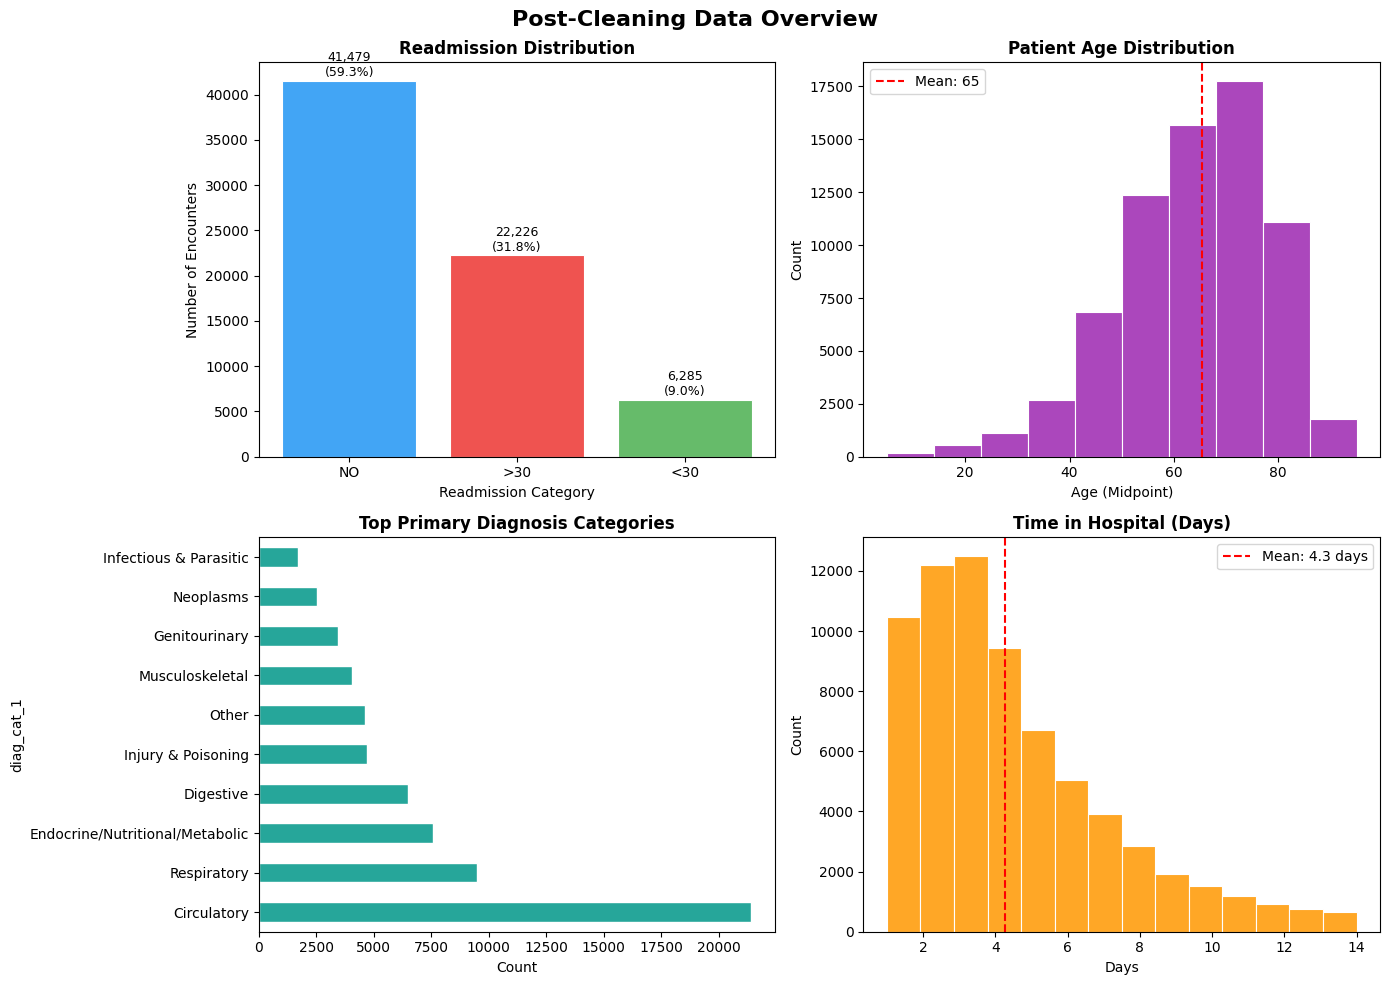

Chart saved: ../data/processed/02_post_cleaning_overview.png


In [91]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Post-Cleaning Data Overview', fontsize=16, fontweight='bold')

# Plot 1: Readmission distribution
ax = axes[0, 0]
readmit_counts = df['readmitted'].value_counts()
colors = ['#42A5F5', '#EF5350', '#66BB6A']
bars = ax.bar(readmit_counts.index, readmit_counts.values,
              color=colors[:len(readmit_counts)], edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, readmit_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=9)
ax.set_title('Readmission Distribution', fontweight='bold')
ax.set_ylabel('Number of Encounters')
ax.set_xlabel('Readmission Category')

# Plot 2: Age distribution
ax = axes[0, 1]
ax.hist(df['age'], bins=10, color='#AB47BC', edgecolor='white', linewidth=0.8)
ax.set_title('Patient Age Distribution', fontweight='bold')
ax.set_xlabel('Age (Midpoint)')
ax.set_ylabel('Count')
ax.axvline(df['age'].mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Mean: {df["age"].mean():.0f}')
ax.legend()

# Plot 3: Primary diagnosis category
ax = axes[1, 0]
diag_counts = df['diag_cat_1'].value_counts().head(10)
diag_counts.plot(kind='barh', ax=ax, color='#26A69A', edgecolor='white')
ax.set_title('Top Primary Diagnosis Categories', fontweight='bold')
ax.set_xlabel('Count')

# Plot 4: Time in hospital distribution
ax = axes[1, 1]
ax.hist(df['time_in_hospital'], bins=14, color='#FFA726', edgecolor='white', linewidth=0.8)
ax.set_title('Time in Hospital (Days)', fontweight='bold')
ax.set_xlabel('Days')
ax.set_ylabel('Count')
ax.axvline(df['time_in_hospital'].mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Mean: {df["time_in_hospital"].mean():.1f} days')
ax.legend()

plt.tight_layout()
chart_path = PROCESSED_DIR + '02_post_cleaning_overview.png'
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved: {chart_path}')

## Cell 20 — Export Cleaned Dataset & Write Log

In [92]:
# Export cleaned CSV
df.to_csv(PROCESSED_PATH, index=False)
file_mb = os.path.getsize(PROCESSED_PATH) / 1e6

record(14, f'FINAL EXPORT: {PROCESSED_PATH} | {len(df):,} rows x {len(df.columns)} cols | {file_mb:.1f} MB')

print(f'Cleaned dataset saved to : {PROCESSED_PATH}')
print(f'File size                : {file_mb:.1f} MB')
print(f'Shape                    : {len(df):,} rows x {len(df.columns)} columns')

# Write transformation log
with open(LOG_PATH, 'w') as f:
    f.write('NST DVA Capstone 2 — ETL Transformation Log\n')
    f.write('Notebook : 02_cleaning.ipynb\n')
    f.write('Dataset  : Diabetic Patient Readmission (Healthcare)\n')
    f.write('Source   : UCI Machine Learning Repository\n')
    f.write('=' * 60 + '\n\n')
    for entry in log:
        f.write(entry + '\n')
    f.write(f'\nTotal transformations: {len(log)}\n')

print(f'\nTransformation log saved : {LOG_PATH}')
print(f'Total steps logged       : {len(log)}')

[STEP 14] FINAL EXPORT: ../data/processed/diabetic_data_clean.csv | 69,990 rows x 85 cols | 24.4 MB
Cleaned dataset saved to : ../data/processed/diabetic_data_clean.csv
File size                : 24.4 MB
Shape                    : 69,990 rows x 85 columns

Transformation log saved : ../data/processed/02_cleaning_log.txt
Total steps logged       : 15


## Cell 21 — Cleaning Summary Table

In [93]:
print('=' * 60)
print('  ETL CLEANING SUMMARY')
print('=' * 60)

summary = [
    ['01', 'Dropped zero-variance columns', 'examide, citoglipton (all "No")'],
    ['02', 'Dropped weight column', '96.9% missing — imputation not viable'],
    ['03', 'Removed deceased/hospice rows', 'ICD discharge IDs 11,13,14,19,20,21'],
    ['04', 'Deduplicated to first encounter', 'Prevents data leakage in readmission study'],
    ['05', 'Filled all missing values', 'Context-appropriate fill per column'],
    ['06', 'Age bracket -> numeric midpoint', '[70-80) -> 75; enables regression'],
    ['07', 'ICD codes -> readable labels', 'admission_type, discharge, source'],
    ['08', 'ICD-9 diagnosis -> categories', '10 disease groups for dashboarding'],
    ['09', 'Medication text -> ordinal codes', '0=No, 1=Steady, 2=Down, 3=Up'],
    ['10', 'Lab results -> ordinal codes', 'max_glu_serum, A1Cresult'],
    ['11', 'Engineered target variable', 'readmitted_30day (binary KPI)'],
    ['12', 'Derived KPI columns', '5 KPIs: utilisation, burden, chronic'],
    ['13', 'Standardised column names', 'lowercase snake_case throughout'],
]

print(f"{'Step':<5} {'Action':<38} {'Justification'}")
print('-' * 80)
for row in summary:
    print(f'{row[0]:<5} {row[1]:<38} {row[2]}')

print()
print(f'Input  : {RAW_ROWS:,} rows x {RAW_COLS} cols')
print(f'Output : {len(df):,} rows x {len(df.columns)} cols')
print(f'Nulls  : {df.isnull().sum().sum()}')
print()
print('  Cleaning complete. Hand off to: notebooks/03_eda.ipynb')
print('=' * 60)

  ETL CLEANING SUMMARY
Step  Action                                 Justification
--------------------------------------------------------------------------------
01    Dropped zero-variance columns          examide, citoglipton (all "No")
02    Dropped weight column                  96.9% missing — imputation not viable
03    Removed deceased/hospice rows          ICD discharge IDs 11,13,14,19,20,21
04    Deduplicated to first encounter        Prevents data leakage in readmission study
05    Filled all missing values              Context-appropriate fill per column
06    Age bracket -> numeric midpoint        [70-80) -> 75; enables regression
07    ICD codes -> readable labels           admission_type, discharge, source
08    ICD-9 diagnosis -> categories          10 disease groups for dashboarding
09    Medication text -> ordinal codes       0=No, 1=Steady, 2=Down, 3=Up
10    Lab results -> ordinal codes           max_glu_serum, A1Cresult
11    Engineered target variable             